In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest

In [19]:
df = pd.read_excel(r"C:\\Users\\nopj2\\OneDrive\\Desktop\\Pranjal_Smart_Meter_Data_Analysis\\Daily_Billing_Load Profile.xlsx", 
                    sheet_name="Load_profile")

df.head(10)

,METER_NUMBER,READS,READ_DTTM,MEASUREMENT_TYPE,MEASUREMENT_TYPE_NAME
0,ABC6779902,24.0,25-08-2025 00:00:00,AVG-SG,UP - Average Signal Strength
1,ABC6779903,24.0,24-08-2025 23:45:00,AVG-SG,UP - Average Signal Strength
2,ABC6779904,23.0,24-08-2025 23:30:00,AVG-SG,UP - Average Signal Strength
3,ABC6779905,25.0,24-08-2025 23:15:00,AVG-SG,UP - Average Signal Strength
4,ABC6779906,24.0,24-08-2025 23:00:00,AVG-SG,UP - Average Signal Strength
5,ABC6779907,24.0,24-08-2025 22:45:00,AVG-SG,UP - Average Signal Strength
6,ABC6779908,25.0,24-08-2025 22:30:00,AVG-SG,UP - Average Signal Strength
7,ABC6779909,24.0,24-08-2025 22:15:00,AVG-SG,UP - Average Signal Strength
8,ABC6779910,24.0,24-08-2025 22:00:00,AVG-SG,UP - Average Signal Strength
9,ABC6779911,24.0,24-08-2025 21:45:00,AVG-SG,UP - Average Signal Strength


In [20]:
#Datetime and pivot the table
df['READ_DTTM'] = pd.to_datetime(df['READ_DTTM'], dayfirst=True, errors='coerce')

df_clean = df.drop_duplicates(subset=['READ_DTTM', 'MEASUREMENT_TYPE_NAME'])

ml_data = df_clean.pivot(index='READ_DTTM',columns='MEASUREMENT_TYPE_NAME',values='READS').dropna()

# Show the results
display(ml_data.head(3))

MEASUREMENT_TYPE_NAME,UP - Average Current,UP - Average Signal Strength,UP - Average Voltage,UP - Block Load Energy KVAH,UP - Block Load Energy KWH,UP - Meter Health Indicator
READ_DTTM,,,,,,
2025-05-01 00:00:00,4.25,26.0,248.01,0.264,0.241,0.0
2025-05-01 00:15:00,3.19,26.0,248.06,0.199,0.178,0.0
2025-05-01 00:30:00,3.18,26.0,248.85,0.198,0.178,0.0


In [21]:
#tThe Isolation Forest model
model = IsolationForest(contamination=0.02, random_state=42)
ml_data['AI_Score'] = model.fit_predict(ml_data)

#Mathematical scoreing (-1 = Anomaly, 1 = Normal)
ml_data['Is_Anomaly'] = ml_data['AI_Score'].apply(lambda x: "Yes" if x == -1 else "No")

# Display how many anomalies were found
ml_data.head(10)
ml_data['Is_Anomaly'].value_counts()

Is_Anomaly
No     10914
Yes      223
Name: count, dtype: int64

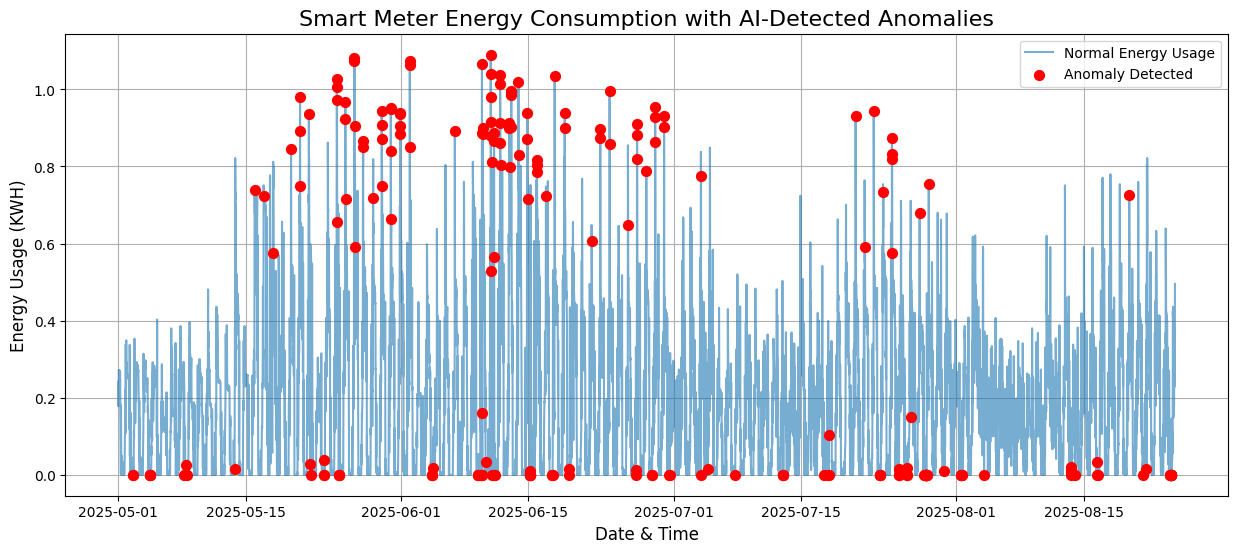

In [25]:
plt.figure(figsize=(15, 6))

plt.plot(ml_data.index, ml_data['UP - Block Load Energy KWH'], label='Normal Energy Usage', color='#1f77b4', alpha=0.6)
anomalies = ml_data[ml_data['Is_Anomaly'] == 'Yes']

plt.scatter(anomalies.index, anomalies['UP - Block Load Energy KWH'], color='red', s=50, label='Anomaly Detected', zorder=5)

plt.title('Smart Meter Energy Consumption with AI-Detected Anomalies', fontsize=16)
plt.xlabel('Date & Time', fontsize=12)
plt.ylabel('Energy Usage (KWH)', fontsize=12)
plt.legend()
plt.grid(True)

# Display the final graph!
plt.show()